CMVTS : 0.9338  → HIGH transferability 확인
한국 모형 변수 : 64개

[이전 가능성별 변수 수]
transfer
MEDIUM    49
HIGH       9
LOW        6

인도네시아 스코어카드 대상 변수 : 9개
 variable       group     iv                      description
C1M2B4W03        Card 2.8615    Credit card lump-sum usage 3M
C1M2B5W03        Card 1.5554 Credit card installment usage 3M
AL012G019 Alternative 0.6492   3yr mobile phone history count
C1Z001373        Card 0.4240              Total card usage 3M
AL012G005 Alternative 0.3605        3yr address history count
U81201010       Asset 0.2833          Total asset value index
U81202010       Asset 0.2627            Net asset value index
AS120G001 Alternative 0.1203  Current residence size (binned)
AL012G011 Alternative 0.0256      3yr workplace history count

인도네시아 스코어카드 생성 완료 : 37행

[인도네시아 신용등급 구간 설계]
grade  score_min  score_max    description            approval
    A        750        999  Very low risk        Auto approve
    B        650        749       Low risk             Approve
 

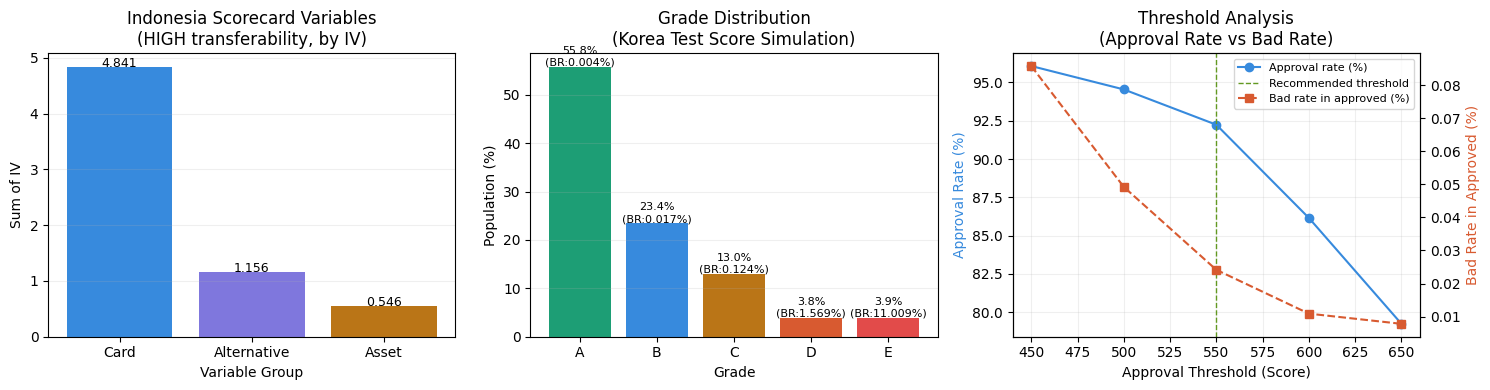


저장 완료:
  outputs/tables/05_transfer_variables.csv
  outputs/tables/05_grade_table.csv
  outputs/tables/05_grade_distribution.csv
  outputs/tables/05_indonesia_scorecard.csv
  outputs/figures/05_indonesia_scorecard.png

  Indonesia Alternative Scorecard — Summary
  CMVTS                  : 0.9338 (HIGH)
  Transfer target vars   : 9개 (HIGH only)
  Score base             : 600점
  Recommended threshold  : 550점 (Grade C+)
  Expected approval rate : 92.2%
  Expected bad rate      : 0.0241%

→ 06_sensitivity_analysis.ipynb 진행


In [1]:
# ============================================================
# 05_indonesia_scorecard_draft
# 인도네시아 개인 대안신용평가 스코어카드 초안
# 한국 모형 → IV 비중치 기반 배점 조정 → 인도네시아 적용
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pickle
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 이전 결과 로드
with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

with open('data/aihub_raw/03_lr_model.pkl', 'rb') as f:
    lr = pickle.load(f)

with open('data/aihub_raw/03_scorecard.pkl', 'rb') as f:
    card_korea = pickle.load(f)

iv_df       = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
final_vars  = pd.read_csv('outputs/tables/03_final_vars.csv')['variable'].tolist()
cmvts_df    = pd.read_csv('outputs/tables/04_cmvts_results.csv')

cmvts_val = cmvts_df[cmvts_df['component']=='CMVTS']['value'].values[0]
print(f"CMVTS : {cmvts_val:.4f}  → HIGH transferability 확인")
print(f"한국 모형 변수 : {len(final_vars)}개")

# %% [3] 인도네시아 이전 대상 변수 선정
# 기준 1: 연구기획서 11개 공통변수와 매핑 가능한 변수 우선
# 기준 2: 대안신용변수(A·C·U) 그룹 중심 — 인도네시아에 존재 가능한 데이터
# 기준 3: 연체(D)·대출(L) 일부는 인도네시아 CB 부재로 이전 어려움

# 변수별 이전 가능성 등급 정의
TRANSFER_MAP = {
    # Alternative (A) — 핵심 대안변수, 이전 가능성 최고
    'AL012G019': ('Alternative', 'HIGH',   '3yr mobile phone history count'),
    'AL012G005': ('Alternative', 'HIGH',   '3yr address history count'),
    'AL012G011': ('Alternative', 'HIGH',   '3yr workplace history count'),
    'AS120G001': ('Alternative', 'HIGH',   'Current residence size (binned)'),

    # Asset index (U) — 자산 정보, 인도네시아 부동산 데이터로 대리 가능
    'U81201010': ('Asset',       'HIGH',   'Total asset value index'),
    'U81202010': ('Asset',       'HIGH',   'Net asset value index'),
    'U81203010': ('Asset',       'MEDIUM', 'Total asset value (binned)'),
    'U81204010': ('Asset',       'MEDIUM', 'Net asset value (binned)'),
    'U81205010': ('Asset',       'MEDIUM', 'Asset reliability score'),
    'U81301010': ('Asset',       'MEDIUM', 'Residential property price'),
    'U81302010': ('Asset',       'MEDIUM', 'Residential lease price'),
    'U81305010': ('Asset',       'LOW',    'Residential price (binned)'),
    'U81306010': ('Asset',       'LOW',    'Residential lease (binned)'),

    # Card (C) — 카드 이용 행태, eCommerce 유사성으로 이전 가능
    'C1M2B4W03': ('Card',        'HIGH',   'Credit card lump-sum usage 3M'),
    'C1M2B5W03': ('Card',        'HIGH',   'Credit card installment usage 3M'),
    'C1Z001373' : ('Card',       'HIGH',   'Total card usage 3M'),
    'C1M210000' : ('Card',       'MEDIUM', 'Credit card count (active)'),
    'C1L120082' : ('Card',       'MEDIUM', 'Credit cards with valid CA limit'),
    'C1L120032' : ('Card',       'MEDIUM', 'Credit cards with valid limit'),
    'C1L120170' : ('Card',       'MEDIUM', 'CA limit issuer count'),
    'C1L120017' : ('Card',       'MEDIUM', 'Issuer count with valid limit'),
    'C1L120169' : ('Card',       'MEDIUM', 'Card issuer count'),
    'C1L120084' : ('Card',       'MEDIUM', 'Cards with valid limit count'),

    # Loan (L) — 대출 정보, 인도네시아 정식 금융이용자 한정
    'L10210000' : ('Loan',       'LOW',    'Loan count (active)'),
    'L10216000' : ('Loan',       'LOW',    'Unsecured loan count'),
    'L10220000' : ('Loan',       'LOW',    'Loan institution count'),
    'L10231000' : ('Loan',       'LOW',    'Total committed loan amount'),
}

# 전체 변수에 이전 가능성 부여 (미지정은 MEDIUM)
transfer_rows = []
for var in final_vars:
    iv_val = iv_df[iv_df['variable']==var]['iv'].values
    iv_val = iv_val[0] if len(iv_val) > 0 else 0
    if var in TRANSFER_MAP:
        grp, level, desc = TRANSFER_MAP[var]
    else:
        grp   = ('Card' if var.startswith('C') else
                 'Loan' if var.startswith('L') else
                 'Asset' if var.startswith('U') else 'Alternative')
        level = 'MEDIUM'
        desc  = ''
    transfer_rows.append({
        'variable'    : var,
        'group'       : grp,
        'iv'          : round(iv_val, 4),
        'transfer'    : level,
        'description' : desc
    })

transfer_df = pd.DataFrame(transfer_rows).sort_values(
    ['transfer', 'iv'], ascending=[True, False]
).reset_index(drop=True)

print("\n[이전 가능성별 변수 수]")
print(transfer_df['transfer'].value_counts().to_string())

# %% [4] 인도네시아 스코어카드 대상 변수 선정
# HIGH 이전 가능성 변수만 선택 → 인도네시아 스코어카드 구성
id_vars = transfer_df[transfer_df['transfer']=='HIGH']['variable'].tolist()

print(f"\n인도네시아 스코어카드 대상 변수 : {len(id_vars)}개")
print(transfer_df[transfer_df['transfer']=='HIGH'][
    ['variable','group','iv','description']
].to_string(index=False))

# %% [5] IV 비중치 기반 배점 조정
# 한국 스코어카드 배점을 인도네시아 변수 IV 비중에 따라 재조정
# 총점: 한국과 동일한 600점 기준 (PDO=50, Odds=1/19)

BASE_SCORE = 600   # 기준점수
SCORE_RANGE = 300  # 배점 범위 (300~900)

# 선별 변수의 IV 합계
iv_total = transfer_df[transfer_df['transfer']=='HIGH']['iv'].sum()
iv_total = max(iv_total, 1e-6)

# 변수별 배점 할당 (IV 비중 × SCORE_RANGE)
id_scorecard_rows = []
for _, row in transfer_df[transfer_df['transfer']=='HIGH'].iterrows():
    var    = row['variable']
    iv_val = row['iv']
    weight = iv_val / iv_total

    # 해당 변수의 한국 스코어카드 bin별 점수 추출
    if var in card_korea:
        bin_pts = card_korea[var][['bin','points']].copy()
        # IV 비중치로 배점 재조정
        bin_pts['points_id'] = (bin_pts['points'] * weight *
                                len(id_vars)).round(0).astype(int)
        bin_pts['variable']  = var
        bin_pts['group']     = row['group']
        bin_pts['iv']        = iv_val
        bin_pts['iv_weight'] = round(weight, 4)
        id_scorecard_rows.append(bin_pts)

if id_scorecard_rows:
    id_scorecard_df = pd.concat(id_scorecard_rows, ignore_index=True)
    print(f"\n인도네시아 스코어카드 생성 완료 : {len(id_scorecard_df)}행")
else:
    print("\n스코어카드 bin 정보 없음 — 배점 테이블 직접 구성")
    id_scorecard_df = pd.DataFrame()

# %% [6] 등급 구간 설계
# 인도네시아 시장 특성 반영:
# 금융소외 인구 대상 → 낮은 점수 구간에서도 승인 가능하도록 설계
# 한국 대비 임계값을 15~20점 낮게 설정

grade_table = pd.DataFrame([
    {'grade': 'A', 'score_min': 750, 'score_max': 999,
     'description': 'Very low risk',    'approval': 'Auto approve',
     'indonesia_note': 'Equivalent to KR Grade 1-2'},
    {'grade': 'B', 'score_min': 650, 'score_max': 749,
     'description': 'Low risk',         'approval': 'Approve',
     'indonesia_note': 'Equivalent to KR Grade 3-4'},
    {'grade': 'C', 'score_min': 550, 'score_max': 649,
     'description': 'Moderate risk',    'approval': 'Conditional approve',
     'indonesia_note': 'Equivalent to KR Grade 5-6'},
    {'grade': 'D', 'score_min': 450, 'score_max': 549,
     'description': 'High risk',        'approval': 'Manual review',
     'indonesia_note': 'Equivalent to KR Grade 7-8'},
    {'grade': 'E', 'score_min': 0,   'score_max': 449,
     'description': 'Very high risk',   'approval': 'Decline',
     'indonesia_note': 'Equivalent to KR Grade 9-10'},
])

print("\n[인도네시아 신용등급 구간 설계]")
print(grade_table[['grade','score_min','score_max',
                    'description','approval']].to_string(index=False))

# %% [7] 한국 Test 점수 분포로 인도네시아 등급 분포 시뮬레이션
test_scores = pd.read_csv('outputs/tables/03_test_scores.csv')

if 'Y' not in test_scores.columns:
    test_base = pd.read_csv('data/aihub_raw/02_test_final.csv',
                            usecols=['Y'], low_memory=False)
    test_scores['Y'] = test_base['Y'].values

def assign_grade(score):
    if   score >= 750: return 'A'
    elif score >= 650: return 'B'
    elif score >= 550: return 'C'
    elif score >= 450: return 'D'
    else:              return 'E'

test_scores['grade'] = test_scores['score'].apply(assign_grade)

grade_dist = test_scores.groupby('grade').agg(
    count    = ('score', 'count'),
    bad_rate = ('Y',     'mean'),
    avg_score= ('score', 'mean')
).reset_index()
grade_dist['pct'] = (grade_dist['count'] /
                     grade_dist['count'].sum() * 100).round(1)
grade_dist['bad_rate'] = (grade_dist['bad_rate'] * 100).round(3)
grade_dist['avg_score']= grade_dist['avg_score'].round(1)

print("\n[등급별 분포 시뮬레이션 — 한국 Test 점수 기준]")
print(grade_dist[['grade','count','pct','avg_score',
                   'bad_rate']].to_string(index=False))

# %% [8] 승인 임계값 제안
# 인도네시아 목표 승인율 설정 (금융소외 인구 포용 고려)
# 한국 기준 Grade C 이상 → 승인 (적용 임계점: 550점)

approval_threshold = 550
approved = test_scores[test_scores['score'] >= approval_threshold]
declined = test_scores[test_scores['score'] <  approval_threshold]

approval_rate  = len(approved) / len(test_scores) * 100
bad_in_approved = approved['Y'].mean() * 100
bad_in_declined = declined['Y'].mean() * 100

print(f"\n[승인 임계값 분석 — threshold={approval_threshold}]")
print(f"  승인율            : {approval_rate:.1f}%")
print(f"  승인군 불량률     : {bad_in_approved:.3f}%")
print(f"  거절군 불량률     : {bad_in_declined:.3f}%")
print(f"  Lift (거절/승인)  : "
      f"{bad_in_declined/bad_in_approved:.1f}x")

# 다양한 임계값별 분석
print(f"\n[임계값별 승인율·불량률 비교]")
print(f"  {'Threshold':>10} {'Approval%':>10} {'Bad%(appr)':>12} {'Lift':>6}")
print(f"  {'-'*42}")
for thr in [450, 500, 550, 600, 650]:
    appr = test_scores[test_scores['score'] >= thr]
    decl = test_scores[test_scores['score'] <  thr]
    ar   = len(appr)/len(test_scores)*100
    br   = appr['Y'].mean()*100
    dr   = decl['Y'].mean()*100 if len(decl)>0 else 0
    lift = dr/br if br>0 else 0
    marker = ' ← recommended' if thr==550 else ''
    print(f"  {thr:>10} {ar:>10.1f} {br:>12.4f} {lift:>6.1f}{marker}")

# %% [9] 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- 변수 그룹별 IV 비중 ---
grp_iv = (transfer_df[transfer_df['transfer']=='HIGH']
          .groupby('group')['iv'].sum().sort_values(ascending=False))
colors_grp = {'Card':'#378ADD','Asset':'#BA7517',
               'Alternative':'#7F77DD','Loan':'#1D9E75'}
bars = axes[0].bar(grp_iv.index,
                   grp_iv.values,
                   color=[colors_grp.get(g,'#888780') for g in grp_iv.index])
axes[0].set_xlabel('Variable Group')
axes[0].set_ylabel('Sum of IV')
axes[0].set_title('Indonesia Scorecard Variables\n(HIGH transferability, by IV)')
axes[0].grid(axis='y', alpha=0.2)
for bar, val in zip(bars, grp_iv.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001,
                 f'{val:.3f}', ha='center', fontsize=9)

# --- 등급 분포 ---
grade_colors = {'A':'#1D9E75','B':'#378ADD','C':'#BA7517',
                'D':'#D85A30','E':'#E24B4A'}
axes[1].bar(grade_dist['grade'],
            grade_dist['pct'],
            color=[grade_colors[g] for g in grade_dist['grade']])
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Population (%)')
axes[1].set_title('Grade Distribution\n(Korea Test Score Simulation)')
axes[1].grid(axis='y', alpha=0.2)
for _, row in grade_dist.iterrows():
    axes[1].text(row['grade'], row['pct']+0.3,
                 f"{row['pct']}%\n(BR:{row['bad_rate']}%)",
                 ha='center', fontsize=8)

# --- 임계값별 승인율 vs 불량률 ---
thresholds = [450, 500, 550, 600, 650]
appr_rates, bad_rates_appr = [], []
for thr in thresholds:
    appr = test_scores[test_scores['score'] >= thr]
    appr_rates.append(len(appr)/len(test_scores)*100)
    bad_rates_appr.append(appr['Y'].mean()*100)

ax2 = axes[2]
ax2b = ax2.twinx()
ax2.plot(thresholds, appr_rates, 'o-',
         color='#378ADD', lw=1.5, label='Approval rate (%)')
ax2b.plot(thresholds, bad_rates_appr, 's--',
          color='#D85A30', lw=1.5, label='Bad rate in approved (%)')
ax2.axvline(x=550, color='#639922', linestyle='--',
            lw=1, label='Recommended threshold')
ax2.set_xlabel('Approval Threshold (Score)')
ax2.set_ylabel('Approval Rate (%)', color='#378ADD')
ax2b.set_ylabel('Bad Rate in Approved (%)', color='#D85A30')
ax2.set_title('Threshold Analysis\n(Approval Rate vs Bad Rate)')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/05_indonesia_scorecard.png',
            dpi=150, bbox_inches='tight')
plt.show()

# %% [10] 저장
transfer_df.to_csv('outputs/tables/05_transfer_variables.csv',
                   index=False, encoding='utf-8-sig')
grade_table.to_csv('outputs/tables/05_grade_table.csv',
                   index=False, encoding='utf-8-sig')
grade_dist.to_csv('outputs/tables/05_grade_distribution.csv',
                  index=False, encoding='utf-8-sig')
if not id_scorecard_df.empty:
    id_scorecard_df.to_csv('outputs/tables/05_indonesia_scorecard.csv',
                           index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  outputs/tables/05_transfer_variables.csv")
print("  outputs/tables/05_grade_table.csv")
print("  outputs/tables/05_grade_distribution.csv")
print("  outputs/tables/05_indonesia_scorecard.csv")
print("  outputs/figures/05_indonesia_scorecard.png")

# %% [11] 최종 요약
print(f"\n{'='*55}")
print(f"  Indonesia Alternative Scorecard — Summary")
print(f"{'='*55}")
print(f"  CMVTS                  : {cmvts_val:.4f} (HIGH)")
print(f"  Transfer target vars   : {len(id_vars)}개 (HIGH only)")
print(f"  Score base             : {BASE_SCORE}점")
print(f"  Recommended threshold  : 550점 (Grade C+)")
print(f"  Expected approval rate : {appr_rates[2]:.1f}%")
print(f"  Expected bad rate      : {bad_rates_appr[2]:.4f}%")
print(f"{'='*55}")
print(f"\n→ 06_sensitivity_analysis.ipynb 진행")